In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

**---Load data---**-

In [2]:

df = pd.read_csv('Agriculture_price_dataset.csv')
df.head()

,STATE,District Name,Market Name,Commodity,Variety,Grade,Min_Price,Max_Price,Modal_Price,Price Date
0,Maharashtra,nashik,Lasalgaon(Niphad),Wheat,Maharashtra 2189,FAQ,2172.0,2399.0,2300.0,6/6/2023
1,Maharashtra,satara,Patan,Tomato,Other,FAQ,1000.0,1500.0,1250.0,6/6/2023
2,Uttar Pradesh,mainpuri,Bewar,Potato,Local,FAQ,800.0,820.0,810.0,6/6/2023
3,Rajasthan,chittorgarh,Nimbahera,Wheat,Other,FAQ,2040.0,2668.0,2300.0,6/6/2023
4,Rajasthan,pratapgarh,Pratapgarh,Onion,Other,FAQ,476.0,1043.0,617.0,6/6/2023


**Find mission value**

In [3]:

print(df.isnull().sum())

STATE            0
District Name    0
Market Name      0
Commodity        0
Variety          0
Grade            0
Min_Price        0
Max_Price        0
Modal_Price      0
Price Date       0
dtype: int64


Date Formatting

In [4]:
df["Price Date"] = pd.to_datetime(df["Price Date"])
df["Year"] = df["Price Date"].dt.year
df["Month"] = df["Price Date"].dt.month
df["Day"] = df["Price Date"].dt.day

In [5]:
print("\n-> Numerical Columns Summary Statistics:")
print(df[["Min_Price", "Max_Price", "Modal_Price"]].describe())

print("\n-> Top Commodities in Dataset (Sorted):")
print(df["Commodity"].value_counts())


-> Numerical Columns Summary Statistics:
           Min_Price      Max_Price    Modal_Price
count  737392.000000  737392.000000  737392.000000
mean     2204.849862    2659.733824    2474.484638
std      1920.977696    2145.250773    2023.851909
min         0.000000       0.000000       0.000000
25%      1100.000000    1500.000000    1300.000000
50%      2000.000000    2300.000000    2150.000000
75%      2700.000000    3205.000000    3000.000000
max    420000.000000  480000.000000  460000.000000

-> Top Commodities in Dataset (Sorted):
Commodity
Potato    327332
Onion     298658
Wheat      76976
Tomato     26644
Rice        7782
Name: count, dtype: int64


**--- EDA ---**


-> Generating EDA Plots...


C:\Users\pawan singh\AppData\Local\Temp\ipykernel_5340\3794123679.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


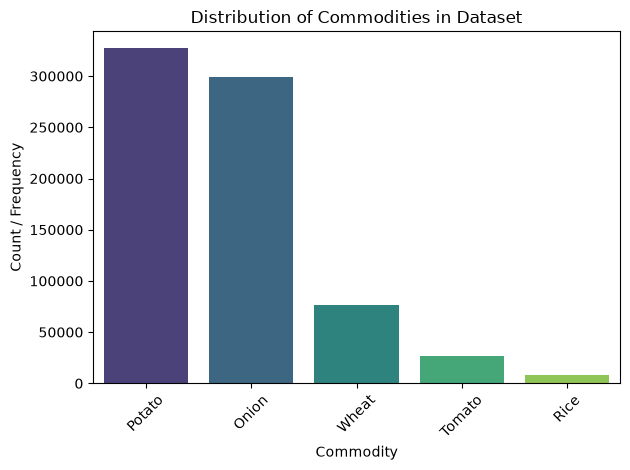

In [6]:

print("\n-> Generating EDA Plots...")

plt.clf()
commodity_counts = df["Commodity"].value_counts().sort_values(ascending=False)
sns.barplot(
    x=commodity_counts.index, y=commodity_counts.values, palette="viridis"
)
plt.title("Distribution of Commodities in Dataset")
plt.xlabel("Commodity")
plt.ylabel("Count / Frequency")
plt.xticks(rotation=45)
plt.tight_layout()


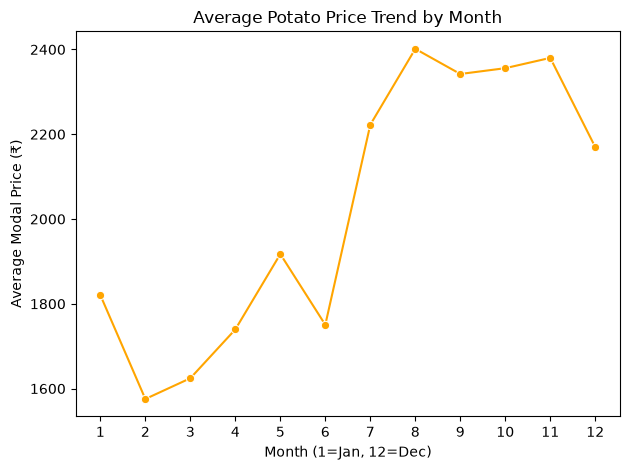

In [7]:

plt.clf()
potato_df = (
    df[df["Commodity"] == "Potato"]
    .groupby("Month")["Modal_Price"]
    .mean()
    .reset_index()
)
sns.lineplot(
    data=potato_df, x="Month", y="Modal_Price", marker="o", color="orange"
)
plt.title("Average Potato Price Trend by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Average Modal Price (₹)")
plt.xticks(range(1, 13))
plt.tight_layout()

**--- DATA PREPROCESSING & FEATURE ENGINEERING ---**

In [8]:

# Missing rows drop karna agar koi bachi ho toh
df = df.dropna()

--- LABEL ENCODING ---

In [9]:

encoders = {}
categorical_cols = ["STATE", "District Name", "Market Name", "Commodity", "Variety"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [10]:

df["Price_Spread_Pct"] = (df["Max_Price"] - df["Min_Price"]) / df["Modal_Price"]
df["Risk_Class"] = np.where(df["Price_Spread_Pct"] > 0.20, 1, 0)


features = ["STATE", "District Name", "Market Name", "Commodity", "Variety", "Month"]

--- MODEL 1 - CROP PRICE PREDICTOR ---

In [11]:

X_price = df[features]
y_price = df["Modal_Price"]

# Fast training ke liye sample use kar rahe hain agar data bohot bada ho
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

--- RandomForestRegressor ---

In [12]:

price_model = RandomForestRegressor(
    n_estimators=50, max_depth=15, random_state=42, n_jobs=-1
)
price_model.fit(X_train_p, y_train_p)

# EvaluatTION
pred_p = price_model.predict(X_test_p)
r2_p = r2_score(y_test_p, pred_p)
print(f"-> Crop Price Predictor Accuracy: {r2_p * 100:.2f}%")

-> Crop Price Predictor Accuracy: 72.80%


--- BEST SELLING TIME PREDICTOR ---

In [18]:
def get_best_selling_time(commodity_name, state_name):
    try:
        comm_encoded = encoders["Commodity"].transform([commodity_name])[0]
        state_encoded = encoders["STATE"].transform([state_name])[0]

        filtered_df = df[
            (df["Commodity"] == comm_encoded) & (df["STATE"] == state_encoded)
        ]

        if filtered_df.empty:
            return "Data not available for this specific combination."

        monthly_avg = (
            filtered_df.groupby("Month")["Modal_Price"].mean().reset_index()
        )
        best_month = monthly_avg.loc[monthly_avg["Modal_Price"].idxmax()]["Month"]

        months_map = {
            1: "January",
            2: "February",
            3: "March",
            4: "April",
            5: "May",
            6: "June",
            7: "July",
            8: "August",
            9: "September",
            10: "October",
            11: "November",
            12: "December",
        }
        return months_map[int(best_month)]
    except Exception as e:
        return f"Error: State/Commodity ka naam check karein. Details: {e}"


print("-> Best Selling Time Engine Ready!")

-> Best Selling Time Engine Ready!


--- MODEL 3 - RISK ANALYSIS MODEL -- -

In [14]:


X_risk = df[features]
y_risk = df["Risk_Class"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_risk, y_risk, test_size=0.2, random_state=42
)


risk_model = RandomForestClassifier(
    n_estimators=50, max_depth=15, random_state=42, n_jobs=-1
)
risk_model.fit(X_train_r, y_train_r)

# Evaluatioin
pred_r = risk_model.predict(X_test_r)
acc_r = accuracy_score(y_test_r, pred_r)
print(f"-> Risk Analysis Model Accuracy Score: {acc_r * 100:.2f}%")

-> Risk Analysis Model Accuracy Score: 89.31%


In [15]:
# =====================================================================
# STEP 6: TIME-BASED SMART CROP PREDICTION SYSTEM
# =====================================================================
print("\n" + "=" * 60)
print("STEP 6: SETUP TIME-BASED CROP PREDICTION ENGINE...")
print("=" * 60)


def predict_best_crop_by_time(state_name, district_name, month_num):
    """
    User se State, District aur Time (Month) lekar us mahine ke liye
    sabse best aur profitable crop recommend karna.
    """
    try:
        # 1. Inputs ko clean aur case-insensitive filter karna
        state_mask = df["STATE"].str.lower() == state_name.lower()
        dist_mask = df["District Name"].str.lower() == district_name.lower()
        month_mask = df["Month"] == int(month_num)

        # 2. Data filter karna user ke inputs ke basis par
        filtered_df = df[state_mask & dist_mask & month_mask]

        if filtered_df.empty:
            return f"⚠️ Maafi chahte hain! {state_name} ke {district_name} district mein Month {month_num} ke liye data available nahi hai."

        # 3. Har crop (Commodity) ke liye average price aur risk calculate karna
        crop_summary = (
            filtered_df.groupby("Commodity")
            .agg({"Modal_Price": "mean", "Risk_Class": "mean"})
            .reset_index()
        )

        # 4. Scoring Logic: High Price ko weight dena aur High Risk ko penalize karna
        # (Risk_Class ka mean jitna 1 ke paas hoga, score utna kam hoga)
        crop_summary["Profit_Score"] = crop_summary["Modal_Price"] * (
            1 - crop_summary["Risk_Class"] * 0.4
        )

        # 5. Sabse highest score waali row nikalna
        best_crop_row = crop_summary.loc[crop_summary["Profit_Score"].idxmax()]
        best_crop_encoded = best_crop_row["Commodity"]

        # 6. Encoded label se asli crop ka naam decode karna
        best_crop_name = encoders["Commodity"].inverse_transform(
            [int(best_crop_encoded)]
        )[0]
        avg_price = best_crop_row["Modal_Price"]
        risk_avg = best_crop_row["Risk_Class"]

        # Risk level ka string message set karna
        if risk_avg < 0.2:
            risk_status = "🟢 LOW RISK (Ekdum Safe Market)"
        elif risk_avg < 0.5:
            risk_status = "🟡 MEDIUM RISK (Thoda Utar-Chadhav Hai)"
        else:
            risk_status = "🔴 HIGH RISK (Market Volatile Hai)"

        # Month name dictionary for clean printing
        months_map = {
            1: "January",
            2: "February",
            3: "March",
            4: "April",
            5: "May",
            6: "June",
            7: "July",
            8: "August",
            9: "September",
            10: "October",
            11: "November",
            12: "December",
        }

        # Result layout render karna
        result = (
            f"\n🌾 ====== TIME-BASED CROP RECOMMENDATION ======\n"
            f"📍 Location         : {state_name.title()}, {district_name.title()}\n"
            f"📅 Selected Time     : {months_map[int(month_num)]}\n"
            f"-----------------------------------------------\n"
            f"🌟 Recommended Crop : {best_crop_name.upper()}\n"
            f"💰 Expected Price    : ₹{avg_price:.2f} per Quintal\n"
            f"⚠️ Market Risk       : {risk_status}\n"
            f"💡 Info              : Pichle data ke hisab se is time par is fasal ka score sabse top raha hai.\n"
            f"==============================================="
        )
        return result

    except Exception as e:
        return f"❌ Error: Kuch toh gadbad hui! Inputs ya spelling check karein. Details: {e}"


print("-> Time-Based Crop Prediction Engine Ready!")


STEP 6: SETUP TIME-BASED CROP PREDICTION ENGINE...
-> Time-Based Crop Prediction Engine Ready!
